<a href="https://colab.research.google.com/github/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/blob/main/Marcel's%20SYEP_Frontier_Technology_Institute_Sustainable_Energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#GitHub & CSV links
github_repo_url = "https://github.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy"
github_repo_url2 = "https://github.com/frontiertechinstitute/datasets/blob/main/Sustainable%20Energy%20Data/sustainable_energy.csv"
RAW_URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-05-26/energy_cleaned.csv"
Income_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/world-bank-income-groups.filtered%20(1990%20-%202010)%20-%20world-bank-income-groups.csv"
change_energy_consumption_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/change-energy-consumption.csv"
GPD_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/8d6d7cd21aacc14fb0f3893c9206efa93b97b59c/Global_Economi_Indicators_Data.csv"

Now, let's update the `classify_income_group` function to use this loaded data. This function will now take both `country_name` and `year` to accurately assign an income group, as a country's income group can change over time.

### RAW DATA
- getting all the info from the already clean raw data that needs further cleaning to create a question.

### Useful Links
GitHub Links:  
- https://github.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy
- https://github.com/frontiertechinstitute/datasets/tree/main/Sustainable%20Energy%20Data

EXCEL/ GOOGLE SHEETS link:
- https://docs.google.com/spreadsheets/d/1kZM9rDKemBRJWe3LN_ooOuFAueEiNO47cbIxYA3evtg/edit?usp=sharing
- https://docs.google.com/spreadsheets/d/1357QsLQOwQhmujFc6_yFXavfhjqWL3wjl9AeHl8zgPk/edit?usp=sharing


Extra Data Sets Links:
- https://data.worldbank.org/
- https://ourworldindata.org/

(Data to preview as an explamle):
- https://ourworldindata.org/energy-production-consumption

- (GPD Data):
- https://data.worldbank.org/indicator/NY.GDP.MKTP.CD?end=2010&start=1990

(Income Groups Data):
- https://ourworldindata.org/world-bank-income-groups-explained#:~:text=Once%20GNI%20per%20capita%20is,others%20with%20populations%20over%2030%2C000.

### Research question:
***- How dose energy sources computation varies over the years across different countries with different income classifications ?***

In [19]:
import pandas as pd

raw_df = pd.read_csv(RAW_URL)
display(raw_df.head(5146)) # Preview the the dataset (can be accsess thorugh google sheets or EXCEL)

,country_name,country_code,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
0,Afghanistan,AFG,1990,NaN,5.000000,NaN,20.360110,34.61567,78.000000,0.0,...,9.661832e+03,0.49400,4.519325e+04,32.166878,3107.90970,NaN,0.0,0.0,NaN,NaN
1,Afghanistan,AFG,1991,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,9.229662e+03,0.49400,4.258417e+04,34.517311,3185.83125,NaN,0.0,0.0,NaN,NaN
2,Afghanistan,AFG,1992,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,8.012857e+03,0.49400,2.900446e+04,41.803092,3349.62180,NaN,0.0,0.0,NaN,NaN
3,Afghanistan,AFG,1993,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,9.402114e+03,0.49400,2.887722e+04,37.706436,3545.20215,NaN,0.0,0.0,NaN,NaN
4,Afghanistan,AFG,1994,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,9.444700e+03,0.49400,2.917647e+04,39.764867,3755.67255,NaN,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5141,West Bank and Gaza,WBG,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5142,West Bank and Gaza,WBG,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5143,West Bank and Gaza,WBG,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5144,West Bank and Gaza,WBG,2010,NaN,NaN,NaN,90.098370,94.13527,95.543853,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
raw_df.info(5146) #View column names, non-null counts, and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5271 entries, 0 to 5270
Data columns (total 52 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   country_name                                                       5271 non-null   object 
 1   country_code                                                       5271 non-null   object 
 2   yr                                                                 5271 non-null   int64  
 3   access_non_solid_fuel_rural_pop_pct                                197 non-null    float64
 4   access_non_solid_fuel_total_pop_pct                                630 non-null    float64
 5   access_non_solid_fuel_urban_pop_pct                                197 non-null    float64
 6   access_electricity_rural_pop_pct                                   696 non-null    float64
 7   access_electricity_total

In [21]:
raw_df.describe() #Get summary statistics for numeric columns

,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,biogas_consumption_terajoules,divisia_decomp_analysis_activity_component_index,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
count,5271.000000,197.000000,630.000000,197.000000,696.000000,696.000000,692.000000,4683.000000,4683.000000,2872.000000,...,4.534000e+03,4683.000000,4.637000e+03,4541.000000,4.683000e+03,3196.000000,4683.000000,4683.000000,1306.000000,1.263000e+03
mean,2000.000000,54.115327,60.208403,75.551069,63.946506,72.872716,84.577451,0.018907,4066.045067,1.430191,...,4.966429e+06,65.139508,7.647936e+06,21.245445,4.956911e+05,15.817747,0.031728,2686.193669,0.191752,1.568623e+04
std,6.055875,38.472578,34.742075,30.369027,37.242464,31.967909,23.318351,0.062921,28758.616649,0.791566,...,2.314921e+07,318.340461,3.624247e+07,29.955535,2.455813e+06,15.335802,0.171642,17094.627698,0.515589,7.105024e+04
min,1990.000000,5.000000,5.000000,5.000000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,1995.000000,13.000000,25.555280,70.000000,28.534595,48.858830,76.998348,0.000000,0.000000,1.025426,...,3.734481e+04,0.165250,5.529487e+04,0.000000,0.000000e+00,7.762815,0.000000,0.000000,0.001471,2.094871e+01
50%,2000.000000,53.429736,72.765372,95.000000,78.045428,88.229380,97.343039,0.000000,0.000000,1.273345,...,1.933980e+05,1.674800,2.636463e+05,2.487794,1.608312e+03,12.339609,0.000000,0.000000,0.013847,2.355756e+02
75%,2005.000000,95.000000,95.000000,95.000000,99.725000,99.955458,100.000000,0.000000,0.000000,1.629765,...,9.950604e+05,13.345000,1.414490e+06,39.807478,4.792682e+04,18.898634,0.000000,0.000000,0.123185,3.513872e+03
max,2010.000000,100.000000,100.000000,100.018099,100.000000,100.000000,100.000000,0.931991,615095.895200,11.648352,...,3.298342e+08,5066.765300,5.344336e+08,100.000000,3.150200e+07,213.043478,2.816079,250459.601000,4.252594,1.050023e+06


In [22]:
raw_df.isnull().sum() #Count missing values in each column

,0
country_name,0
country_code,0
yr,0
access_non_solid_fuel_rural_pop_pct,5074
access_non_solid_fuel_total_pop_pct,4641
access_non_solid_fuel_urban_pop_pct,5074
access_electricity_rural_pop_pct,4575
access_electricity_total_pop_pct,4575
access_electricity_urban_pop_pct,4579
biogas_consumption_tfec_pct,588


In [23]:
raw_df.duplicated().sum() #Count duplicate rows

np.int64(0)

In [24]:
raw_df["country_name"].unique() #View unique values in a column

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Caucasus and Central Asia', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Channel Islands', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba',
       'Curacao', 'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Eastern Asia (including Japan)',
       'Eastern Asia (not including Japan)', 'East

In [25]:
print(raw_df.columns.tolist())

['country_name', 'country_code', 'yr', 'access_non_solid_fuel_rural_pop_pct', 'access_non_solid_fuel_total_pop_pct', 'access_non_solid_fuel_urban_pop_pct', 'access_electricity_rural_pop_pct', 'access_electricity_total_pop_pct', 'access_electricity_urban_pop_pct', 'biogas_consumption_tfec_pct', 'biogas_consumption_terajoules', 'divisia_decomp_analysis_activity_component_index', 'divisia_decomp_analysis_energy_intensity_component_index', 'divisia_decomp_analysis_structure_component_index', 'energy_intensity_level_final_energy_megajoules_per_usd_2005_ppp', 'energy_intensity_level_primary_energy_megajoules_per_usd_2005_ppp', 'energy_intensity_agricultural_sector_megajoules_per_usd_2005', 'energy_intensity_industrial_sector_megajoules_per_usd_2005', 'energy_intensity_other_sectors_megajoules_per_usd_2005', 'energy_savings_primary_energy_terajoules', 'final_to_primary_energy_ratio_pct', 'geothermal_energy_consumption_tfec_pct', 'geothermal_energy_consumption_terajoules', 'hydro_energy_consum

In [26]:
raw_df["country_name"].value_counts() # Count each unique value in a column

,count
country_name,
Afghanistan,21
Albania,21
Algeria,21
American Samoa,21
Andorra,21
...,...
Western Sahara,21
World,21
"Yemen, Rep.",21


In [27]:
# List of key numerical variables to analyze
key_variables = [
    'access_electricity_total_pop_pct',
    'access_electricity_rural_pop_pct',
    'access_electricity_urban_pop_pct',
    'renewable_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'wind_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_installed_capacity_gigawatts',
    'total_installed_generation_capacity_gigawatts',
    'energy_intensity_level_final_energy_megajoules_per_usd_2005_ppp',
    'total_final_energy_consumption_tfec'
]

# Display summary statistics for each key variable
for col in key_variables:
    if col in raw_df.columns:
        print(f"\n--- Summary statistics for {col} ---")
        display(raw_df[col].describe())
    else:
        print(f"\n--- Column '{col}' not found in DataFrame ---")


--- Summary statistics for access_electricity_total_pop_pct ---


,access_electricity_total_pop_pct
count,696.000000
mean,72.872716
std,31.967909
min,0.100000
25%,48.858830
50%,88.229380
75%,99.955458
max,100.000000



--- Summary statistics for access_electricity_rural_pop_pct ---


,access_electricity_rural_pop_pct
count,696.000000
mean,63.946506
std,37.242464
min,0.100000
25%,28.534595
50%,78.045428
75%,99.725000
max,100.000000



--- Summary statistics for access_electricity_urban_pop_pct ---


...

,total_installed_generation_capacity_gigawatts
count,4683.000000
mean,65.139508
std,318.340461
min,0.000000
25%,0.165250
50%,1.674800
75%,13.345000
max,5066.765300



--- Summary statistics for energy_intensity_level_final_energy_megajoules_per_usd_2005_ppp ---


,energy_intensity_level_final_energy_megajoules_per_usd_2005_ppp
count,4102.000000
mean,8.544423
std,10.702171
min,0.122324
25%,3.928692
50%,5.536100
75%,9.269442
max,204.429924



--- Summary statistics for total_final_energy_consumption_tfec ---


,total_final_energy_consumption_tfec
count,4.534000e+03
mean,4.966429e+06
std,2.314921e+07
min,0.000000e+00
25%,3.734481e+04
50%,1.933980e+05
75%,9.950604e+05
max,3.298342e+08


### Further Cleaning
Want to answer One of of Two Questions:
- Do high income counties create a higher % of their engery from their renewable soruces than low income or mid income counties in 2000 vs 2010
(Develped vs underdevelped counties)


Or

- Which energy source gives the Unidted states the most total engery compostion Old renwable soruces like hydro vs. New renwable soruces like solar.2000 vs 2010
(old vs New renwable soruces)

### Finding High Income, Middle Income, & Low income countries.


Let's clean and standardize the `raw_df` country names and filter out aggregate entities before applying the income classification.

In [28]:
country_name_mapping = {
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Russian Federation': 'Russia',
    'Slovak Republic': 'Slovakia',
    'Taiwan, China': 'Taiwan',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Hong Kong SAR, China': 'Hong Kong',
    'Bahamas, The': 'Bahamas'
}
raw_df['country_name'] = raw_df['country_name'].replace(country_name_mapping)

# Define a list of non-country entities (aggregate regions or non-standard territories)
# These should not be classified by the individual country income group dataset
non_country_entities_to_filter = [
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'Channel Islands', 'American Samoa', 'Andorra', 'Aruba', 'Bermuda',
    'British Virgin Islands', 'Cayman Islands', 'Cook Islands', 'Curacao',
    'Dominica', 'Faeroe Islands', 'Falkland Islands', 'French Guyana',
    'French Polynesia', 'Gibraltar', 'Greenland', 'Guadeloupe', 'Guam',
    'Isle of Man', 'Kiribati', 'Liechtenstein', 'Marshall Islands',
    'Martinique', 'Mayotte', 'Micronesia, Fed. Sts.', 'Monaco', 'Montserrat',
    'New Caledonia', 'Netherlands Antilles', 'Northern Mariana Islands', 'Palau',
    'Puerto Rico', 'Qatar', 'Reunion', 'Saint Pierre et Miquelon', 'Samoa',
    'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Sint Maarten (Dutch part)',
    'Solomon Islands', 'St. Kitts and Nevis', 'St. Lucia', 'St. Martin (French part)',
    'St. Vincent and the Grenadines', 'Suriname', 'Swaziland', 'Timor-Leste', 'Togo',
    'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Virgin Islands (U.S.)',
    'Western Sahara', 'Kosovo', 'Lao PDR', 'Macao SAR, China', 'South Sudan',
    'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire"
]

# Filter out these non-country entities from raw_df
raw_df = raw_df[~raw_df['country_name'].isin(non_country_entities_to_filter)].copy()

print(f"Shape of raw_df after cleaning and filtering non-country entities: {raw_df.shape}")
print("--- Sample of raw_df country names after cleaning ---")
display(raw_df['country_name'].unique()[:20])

# Verify if problematic countries are now present in raw_df for the specific year 2000
problem_countries = ['Brazil', 'Mexico', 'South Africa']
check_year = 2000
print(f"\n--- Verifying problematic Middle Income countries in the cleaned raw_df for year {check_year} ---")
for country in problem_countries:
    if not raw_df[(raw_df['country_name'] == country) & (raw_df['yr'] == check_year)].empty:
        print(f"{country} is now found in the cleaned raw_df for year {check_year}.")
    else:
        print(f"{country} is still MISSING from the cleaned raw_df for year {check_year}.")

Shape of raw_df after cleaning and filtering non-country entities: (3528, 52)
--- Sample of raw_df country names after cleaning ---


array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia'], dtype=object)


--- Verifying problematic Middle Income countries in the cleaned raw_df for year 2000 ---
Brazil is now found in the cleaned raw_df for year 2000.
Mexico is now found in the cleaned raw_df for year 2000.
South Africa is now found in the cleaned raw_df for year 2000.


In [29]:
# Load the income group data
income_group_df = pd.read_csv(Income_URL)

# Rename columns for easier access and consistency
income_group_df = income_group_df.rename(columns={'Entity': 'country_name', 'Year': 'yr', "World Bank's income classification": 'income_group'})

# Drop columns that are not needed after renaming
income_group_df = income_group_df.drop(columns=['Code'], errors='ignore')

# Ensure 'yr' is integer type
income_group_df['yr'] = income_group_df['yr'].astype(int)

# Clean country names in income_group_df by stripping whitespace
income_group_df['country_name'] = income_group_df['country_name'].str.strip()

print("--- Income Group Data Preview ---")
display(income_group_df.head())

print("--- Income Group Data Info ---")
display(income_group_df.info())

print("--- Unique Income Groups in Loaded Data ---")
display(income_group_df['income_group'].unique())

--- Income Group Data Preview ---


,country_name,yr,income_group
0,Afghanistan,1990,Low-income countries
1,Afghanistan,1991,Low-income countries
2,Afghanistan,1992,Low-income countries
3,Afghanistan,1993,Low-income countries
4,Afghanistan,1994,Low-income countries


--- Income Group Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4382 entries, 0 to 4381
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_name  4382 non-null   object
 1   yr            4382 non-null   int64 
 2   income_group  4382 non-null   object
dtypes: int64(1), object(2)
memory usage: 102.8+ KB


None

--- Unique Income Groups in Loaded Data ---


array(['Low-income countries', 'Lower-middle-income countries',
       'Upper-middle-income countries', 'High-income countries'],
      dtype=object)

In [30]:
# Merge income_group_df into raw_df to add the 'income_group' column
# Use a left merge to keep all entries from raw_df and add corresponding income groups
print(f"Shape of raw_df before merge: {raw_df.shape}")
raw_df = pd.merge(raw_df, income_group_df, on=['country_name', 'yr'], how='left')
print(f"Shape of raw_df after merge: {raw_df.shape}")

print("--- Sample of raw_df after merging with income_group_df ---")
display(raw_df[['country_name', 'yr', 'income_group']].head())

print("--- Distribution of Income Groups after Merge ---")
display(raw_df['income_group'].value_counts(dropna=False))

Shape of raw_df before merge: (3528, 52)
Shape of raw_df after merge: (3528, 53)
--- Sample of raw_df after merging with income_group_df ---


,country_name,yr,income_group
0,Afghanistan,1990,Low-income countries
1,Afghanistan,1991,Low-income countries
2,Afghanistan,1992,Low-income countries
3,Afghanistan,1993,Low-income countries
4,Afghanistan,1994,Low-income countries


--- Distribution of Income Groups after Merge ---


,count
income_group,
Low-income countries,1025
Lower-middle-income countries,948
High-income countries,740
Upper-middle-income countries,590
NaN,225


In [31]:
print("--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---")
display(raw_df['income_group'].value_counts())

us_income_group = raw_df[raw_df['country_name'] == 'United States']['income_group'].unique()
if len(us_income_group) > 0:
    print(f"The United States is classified as: {us_income_group[0]}")
else:
    print("The United States is not found or not classified in the current data.")

india_income_group = raw_df[raw_df['country_name'] == 'India']['income_group'].unique()
if len(india_income_group) > 0:
    print(f"India is classified as: {india_income_group[0]}")
else:
    print("India is not found or not classified in the current data.")

--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---


,count
income_group,
Low-income countries,1025
Lower-middle-income countries,948
High-income countries,740
Upper-middle-income countries,590


The United States is classified as: High-income countries
India is classified as: Low-income countries


In [32]:
def classify_income_group_from_df(country_name, year, income_df):
    problematic_countries_for_debug = ['Brazil', 'Mexico', 'South Africa']
    check_year_for_debug = [1990, 2000, 2010]

    # Debug print for specific problematic countries and years
    if country_name in problematic_countries_for_debug and year in check_year_for_debug:
        print(f"DEBUG: classify_income_group_from_df called for {country_name} (Year: {year})")
        print(f"DEBUG: Type of country_name: {type(country_name)}, Type of year: {type(year)})")
        print(f"DEBUG: Looking for country_name='{country_name}' and year={year} in income_df")

    country_year_data = income_df[(income_df['country_name'] == country_name) & (income_df['yr'] == year)]

    if not country_year_data.empty:
        detailed_group = country_year_data['income_group'].iloc[0]

        if country_name in problematic_countries_for_debug and year in check_year_for_debug:
            print(f"DEBUG: Inside classify_income_group_from_df. Found detailed_group: '{detailed_group}'")
            print(f"DEBUG:   Condition 1 ('High-income' in detailed_group): {'High-income' in detailed_group}")
            print(f"DEBUG:   Condition 2 ('middle-income' in detailed_group.lower()): {'middle-income' in detailed_group.lower()}")
            print(f"DEBUG:   Condition 3 ('Low-income' in detailed_group): {'Low-income' in detailed_group}")

        # Map detailed groups to broader categories
        if 'High-income' in detailed_group:
            return 'High Income'
        elif 'middle-income' in detailed_group.lower():
            return 'Middle Income'
        elif 'Low-income' in detailed_group:
            return 'Low Income'
        else:
            if country_name in problematic_countries_for_debug and year in check_year_for_debug:
                print(f"DEBUG: Took 'else' branch for '{country_name}', returning 'Not Classified' (detailed_group: {detailed_group})")
            return 'Not Classified'
    else:
        if country_name in problematic_countries_for_debug and year in check_year_for_debug:
            print(f"DEBUG: country_year_data is empty for '{country_name}', returning 'Not Classified'")
        return 'Not Classified'

In [33]:
print("--- Distribution of Income Groups after DataFrame-based Classification ---")
display(raw_df['income_group'].value_counts())

--- Distribution of Income Groups after DataFrame-based Classification ---


,count
income_group,
Low-income countries,1025
Lower-middle-income countries,948
High-income countries,740
Upper-middle-income countries,590


In [34]:
# Apply the classification function using income_group_df and directly update the 'income_group' column

def diagnostic_classify(row):
    country = row['country_name']
    year = row['yr']
    return classify_income_group_from_df(country, year, income_group_df)

raw_df['income_group'] = raw_df.apply(diagnostic_classify, axis=1)

print("--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---")
display(raw_df['income_group'].value_counts())

print("--- Sample of Income Group Classification ---")
display(raw_df[['country_name', 'yr', 'income_group']].sample(10))

DEBUG: classify_income_group_from_df called for Brazil (Year: 1990)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Brazil' and year=1990 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-middle-income countries'
DEBUG:   Condition 1 ('High-income' in detailed_group): False
DEBUG:   Condition 2 ('middle-income' in detailed_group.lower()): True
DEBUG:   Condition 3 ('Low-income' in detailed_group): False
DEBUG: classify_income_group_from_df called for Brazil (Year: 2000)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Brazil' and year=2000 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-middle-income countries'
DEBUG:   Condition 1 ('High-income' in detailed_group): False
DEBUG:   Condition 2 ('middle-income' in detailed_group.lower()): True
DEBUG:   Condition 3 ('Low-income' in detailed_group): Fa

,count
income_group,
Middle Income,1538
Low Income,1025
High Income,740
Not Classified,225


--- Sample of Income Group Classification ---


,country_name,yr,income_group
252,Bangladesh,1990,Low Income
2539,Pakistan,2009,Middle Income
3,Afghanistan,1993,Low Income
2561,Panama,2010,Middle Income
2605,Peru,1991,Middle Income
1620,Israel,1993,High Income
1438,Honduras,2000,Middle Income
3344,Uruguay,1995,Middle Income
1337,Guatemala,2004,Middle Income
3255,Ukraine,1990,Not Classified


In [35]:
# Drop any Income countries that are not classified through the Raw Data set
print(f"Raw data shape before dropping 'Not Classified' rows: {raw_df.shape}")
raw_df = raw_df[raw_df['income_group'] != 'Not Classified'].copy()
print(f"Raw data after dropping 'Not Classified' rows: {raw_df.shape}")

Raw data shape before dropping 'Not Classified' rows: (3528, 53)
Raw data after dropping 'Not Classified' rows: (3303, 53)


In [36]:
# Filter for years 1990, 2000 and 2010
years_to_analyze = [1990, 2000, 2010]
filtered_years_df = raw_df[raw_df['yr'].isin(years_to_analyze)].copy()

# Filter for classified income groups only (excluding 'Not Classified')
# This step is technically redundant now that 'Not Classified' rows have been dropped from raw_df,
# but it's kept for robustness if raw_df were to be reloaded without re-classification.
classified_income_df = filtered_years_df[filtered_years_df['income_group'] != 'Not Classified']

# Group by year and income_group and calculate the mean of renewable energy consumption percentage
renewable_energy_by_income_group = classified_income_df.groupby(['yr', 'income_group'])['renewable_energy_consumption_tfec_pct'].mean().unstack()

print("Average Renewable Energy Consumption (TFEC %) by Income Group for 1990, 2000 and 2010:")
display(renewable_energy_by_income_group)

Average Renewable Energy Consumption (TFEC %) by Income Group for 1990, 2000 and 2010:


income_group,High Income,Low Income,Middle Income
yr,,,
1990,12.509133,74.387536,29.996885
2000,13.800071,65.468733,23.237824
2010,14.780454,71.445238,27.610545


In [37]:
# Filter for years 1990 & 2000 & 2010
years_to_analyze = [1990, 2000, 2010]
filtered_years_df = raw_df[raw_df['yr'].isin(years_to_analyze)].copy()

# Filter for classified income groups only (excluding 'Not Classified')
classified_income_df = filtered_years_df[filtered_years_df['income_group'] != 'Not Classified']

# Group by year & income_group & calculate the mean of renewable energy
# consumption percentage
renewable_energy_by_income_group = classified_income_df.groupby(['yr', 'income_group'])['renewable_energy_consumption_tfec_pct'].mean().unstack()

print("Average Renewable Energy Consumption (TFEC %) by Income Group for 2000 and 2010:")
display(renewable_energy_by_income_group)

Average Renewable Energy Consumption (TFEC %) by Income Group for 2000 and 2010:


income_group,High Income,Low Income,Middle Income
yr,,,
1990,12.509133,74.387536,29.996885
2000,13.800071,65.468733,23.237824
2010,14.780454,71.445238,27.610545


In [39]:
# Define generic income group names to exclude (these are not individual countries)
generic_income_group_names = [
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'European Union'
]

# Find other High Income countries (excluding generic group names)
high_income_countries = raw_df[
    (raw_df['income_group'] == 'High Income') &
    (~raw_df['country_name'].isin(generic_income_group_names))
]['country_name'].unique()

print("\n--- Other High Income Countries (examples) ---")
display(high_income_countries[:5]) # Display first 5 for brevity


--- Other High Income Countries (examples) ---


array(['Antigua and Barbuda', 'Australia', 'Austria', 'Bahamas',
       'Bahrain'], dtype=object)

### All Classified Countries by Income Group

In [40]:
high_income_countries_full = raw_df[raw_df['income_group'] == 'High Income']['country_name'].unique().tolist()
middle_income_countries_full = raw_df[raw_df['income_group'] == 'Middle Income']['country_name'].unique().tolist()
low_income_countries_full = raw_df[raw_df['income_group'] == 'Low Income']['country_name'].unique().tolist()

# Create a dictionary to hold the lists, using pd.Series to handle unequal lengths
data = {
    'High Income Countries': pd.Series(high_income_countries_full),
    'Middle Income Countries': pd.Series(middle_income_countries_full),
    'Low Income Countries': pd.Series(low_income_countries_full)
}

# Create a DataFrame from the dictionary
all_classified_countries_df = pd.DataFrame(data)

print("\n--- All Classified Countries by Income Group ---")
display(all_classified_countries_df)


--- All Classified Countries by Income Group ---


,High Income Countries,Middle Income Countries,Low Income Countries
0,Antigua and Barbuda,Albania,Afghanistan
1,Australia,Algeria,Albania
2,Austria,Angola,Angola
3,Bahamas,Antigua and Barbuda,Armenia
4,Bahrain,Argentina,Azerbaijan
...,...,...,...
98,NaN,Venezuela,NaN
99,NaN,Vietnam,NaN
100,NaN,Yemen,NaN
101,NaN,Zambia,NaN


### Graph From Raw Data

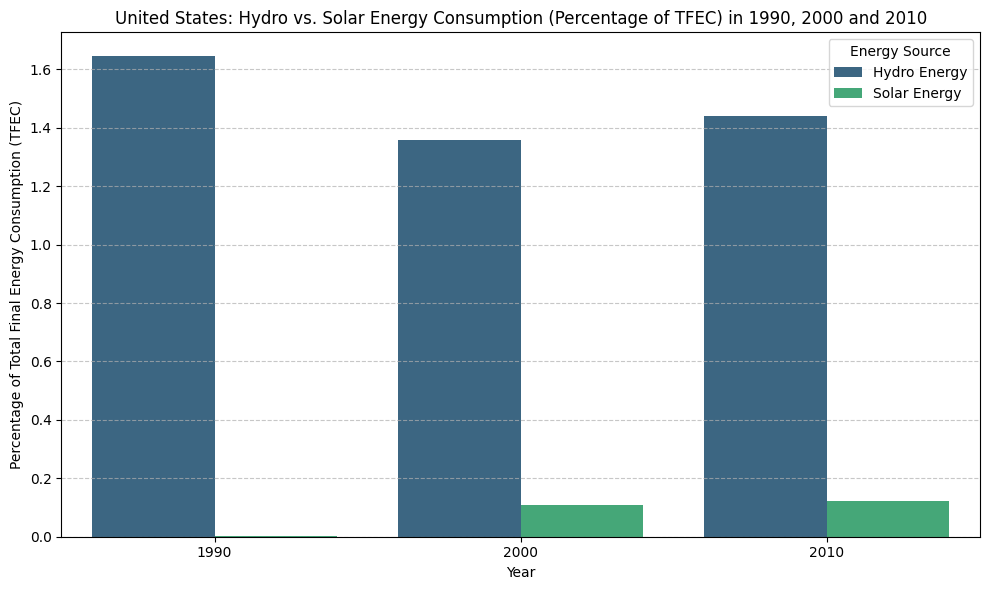

In [41]:
#Make the Plot for the data that I want to anaylze
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for United States and years 1990, 2000, 2010
us_energy_data = raw_df[
    (raw_df['country_name'] == 'United States') &
    (raw_df['yr'].isin([1990, 2000, 2010]))
][['yr', 'hydro_energy_consumption_tfec_pct', 'solar_energy_consumption_tfec_pct']]

# Melt the DataFrame for easier plotting
us_energy_melted = us_energy_data.melt(
    id_vars=['yr'],
    value_vars=['hydro_energy_consumption_tfec_pct', 'solar_energy_consumption_tfec_pct'],
    var_name='energy_source',
    value_name='percentage_tfec'
)

# Map column names for better readability on the plot
us_energy_melted['energy_source'] = us_energy_melted['energy_source'].map({
    'hydro_energy_consumption_tfec_pct': 'Hydro Energy',
    'solar_energy_consumption_tfec_pct': 'Solar Energy'
})

# Create the bar plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(
    x='yr',
    y='percentage_tfec',
    hue='energy_source',
    data=us_energy_melted,
    palette='viridis'
)

plt.title('United States: Hydro vs. Solar Energy Consumption (Percentage of TFEC) in 1990, 2000 and 2010')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Final Energy Consumption (TFEC)')
plt.legend(title='Energy Source')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Row/Column Droping

In [45]:
#Drop the cloums / rows that im not focusing on

columns_to_drop = ['access_electricity_total_pop_pct', 'access_electricity_rural_pop_pct', 'access_electricity_urban_pop_pct', 'renewable_energy_installed_capacity_gigawatts', 'total_installed_generation_capacity_gigawatts']

In [46]:
raw_df = raw_df.drop(columns=columns_to_drop, errors='ignore')

In [47]:
# List to store indices of rows to be dropped (if any)
rows_to_drop = []

In [48]:
selected_countries = ['United States', 'India', 'Afghanistan']
selected_columns = [
    'country_name',
    'yr',
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Filter the DataFrame for the selected countries and columns
filtered_energy_df = raw_df[raw_df['country_name'].isin(selected_countries)][selected_columns]

# Display the first few rows of the new DataFrame
display(filtered_energy_df.head(63))

,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,total_final_energy_consumption_tfec
0,Afghanistan,1990,NaN,0.000000,0.000000,10.195503,9.661832e+03
1,Afghanistan,1991,NaN,0.000000,0.000000,9.545578,9.229662e+03
2,Afghanistan,1992,NaN,0.000000,0.000000,8.981214,8.012857e+03
3,Afghanistan,1993,NaN,0.000000,0.000000,17.009797,9.402114e+03
4,Afghanistan,1994,NaN,NaN,NaN,16.760214,9.444700e+03
...,...,...,...,...,...,...,...
3334,United States,2006,0.142027,0.154012,0.097745,1.553949,5.889579e+07
3335,United States,2007,0.184355,0.161998,0.101666,1.329897,5.979761e+07
3336,United States,2008,0.300547,0.108517,0.109124,1.385283,5.858019e+07
3337,United States,2009,0.419489,0.112809,0.117520,1.557499,5.570889e+07


## Convert columns to numeric, coercing non-numeric values to NaN

In [49]:
# Create a copy of the DataFrame to apply numeric conversion
filtered_energy_df_numeric = filtered_energy_df.copy()

# Columns to convert to numeric
energy_cols_to_convert = [
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct'
]

for col in energy_cols_to_convert:
    if col in filtered_energy_df_numeric.columns:
        filtered_energy_df_numeric[col] = pd.to_numeric(filtered_energy_df_numeric[col], errors='coerce')

# Display info to confirm data types in the new DataFrame
print("Data types after conversion in filtered_energy_df_numeric:")
display(filtered_energy_df_numeric.info())

Data types after conversion in filtered_energy_df_numeric:
<class 'pandas.core.frame.DataFrame'>
Index: 63 entries, 0 to 3338
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country_name                            63 non-null     object 
 1   yr                                      63 non-null     int64  
 2   wind_energy_consumption_tfec_pct        42 non-null     float64
 3   geothermal_energy_consumption_tfec_pct  46 non-null     float64
 4   solar_energy_consumption_tfec_pct       46 non-null     float64
 5   hydro_energy_consumption_tfec_pct       62 non-null     float64
 6   total_final_energy_consumption_tfec     62 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 3.9+ KB


None

In [50]:
print("Missing values in filtered_energy_df_numeric after conversion:")
display(filtered_energy_df_numeric.isnull().sum())

Missing values in filtered_energy_df_numeric after conversion:


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,21
geothermal_energy_consumption_tfec_pct,17
solar_energy_consumption_tfec_pct,17
hydro_energy_consumption_tfec_pct,1
total_final_energy_consumption_tfec,1


## Creating a DataFrame with a Broader Set of Countries

To provide a more comprehensive dataset for analysis, we will create a single DataFrame that combines a curated list of countries, carefully categorized into High, Middle, and Low-income groups.

This selection ensures a balanced representation across different economic classifications for our analysis:

*   **High Income Countries:** United States, Australia, Japan, Spain, France
*   **Middle Income Countries:** India, Brazil, Mexico, South Africa
*   **Low Income Countries:** Afghanistan, Ethiopia, Chad, Niger

We will then apply the necessary data filtering, numeric conversion, and missing value imputation steps to this combined dataset to prepare it for further analysis.

In [51]:
import pandas as pd

# Define the comprehensive list of countries
final_selected_countries = [
    'United States', 'India', 'Afghanistan',
    'Australia', 'Brazil', 'Ethiopia',
    'Japan', 'Spain', 'Mexico', 'South Africa',
    'France', 'Chad', 'Niger'
]

# Use the same selected columns as before for energy consumption data
final_selected_columns = [
    'country_name',
    'yr',
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Filter the raw_df for this comprehensive set of countries and columns
final_combined_energy_df = raw_df[raw_df['country_name'].isin(final_selected_countries)][final_selected_columns].copy()

# Create a copy for numeric conversion and imputation
final_combined_energy_df_numeric = final_combined_energy_df.copy()

# Columns to convert to numeric
energy_cols_to_convert_final = [
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Convert to numeric, coercing non-numeric values to NaN
for col in energy_cols_to_convert_final:
    if col in final_combined_energy_df_numeric.columns:
        final_combined_energy_df_numeric[col] = pd.to_numeric(final_combined_energy_df_numeric[col], errors='coerce')

# Fill missing values using the same imputation method:
# 1. Country-specific median
# 2. Overall column median (if any NaNs remain)
for col in energy_cols_to_convert_final:
    if col in final_combined_energy_df_numeric.columns:
        final_combined_energy_df_numeric[col] = final_combined_energy_df_numeric.groupby('country_name')[col].transform(lambda x: x.fillna(x.median()))
        if final_combined_energy_df_numeric[col].isnull().any():
            global_median = final_combined_energy_df_numeric[col].median()
            final_combined_energy_df_numeric[col] = final_combined_energy_df_numeric[col].fillna(global_median)

# Apply the previously defined classify_income_group_from_df function
# This function uses income_group_df (loaded from Income_URL) for classification
final_combined_energy_df_numeric['income_group'] = final_combined_energy_df_numeric.apply(
    lambda row: classify_income_group_from_df(row['country_name'], row['yr'], income_group_df), axis=1
)

print("Final Combined DataFrame with imputed values and Income Groups:")
display(final_combined_energy_df_numeric.head())

print("Missing values in final_combined_energy_df_numeric after imputation:")
display(final_combined_energy_df_numeric.isnull().sum())

DEBUG: classify_income_group_from_df called for Brazil (Year: 1990)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Brazil' and year=1990 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-middle-income countries'
DEBUG:   Condition 1 ('High-income' in detailed_group): False
DEBUG:   Condition 2 ('middle-income' in detailed_group.lower()): True
DEBUG:   Condition 3 ('Low-income' in detailed_group): False
DEBUG: classify_income_group_from_df called for Brazil (Year: 2000)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Brazil' and year=2000 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-middle-income countries'
DEBUG:   Condition 1 ('High-income' in detailed_group): False
DEBUG:   Condition 2 ('middle-income' in detailed_group.lower()): True
DEBUG:   Condition 3 ('Low-income' in detailed_group): Fa

,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group
0,Afghanistan,1990,0.011164,0.0,0.0,10.195503,42.362380,9661.83210,Low Income
1,Afghanistan,1991,0.011164,0.0,0.0,9.545578,44.062889,9229.66245,Low Income
2,Afghanistan,1992,0.011164,0.0,0.0,8.981214,50.784306,8012.85660,Low Income
3,Afghanistan,1993,0.011164,0.0,0.0,17.009797,54.716233,9402.11415,Low Income
4,Afghanistan,1994,0.011164,0.0,0.0,16.760214,56.525081,9444.70035,Low Income


Missing values in final_combined_energy_df_numeric after imputation:


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0


In [52]:
# Define the countries and their expected income groups from the user's request
countries_to_check = {
    'High Income': ['United States', 'Australia', 'Japan', 'Spain', 'France'],
    'Middle Income': ['India', 'Brazil', 'Mexico', 'South Africa'],
    'Low Income': ['Afghanistan', 'Ethiopia', 'Chad', 'Niger']
}

print("Verifying income group classifications from income_group_df (for year 2000) after re-running cleaning and classification:\n")

for expected_group, country_list in countries_to_check.items():
    print(f"--- Expected {expected_group} Countries ---")
    for country in country_list:
        # Use the classify_income_group_from_df function with income_group_df
        classified_group = classify_income_group_from_df(country, 2000, income_group_df)
        status = "CORRECT" if classified_group == expected_group else f"INCORRECT (Classified as: {classified_group})"
        print(f"  {country}: {status}")
    print("\n")

# A quick check for a country that might be 'Not Classified' to ensure the function works as expected
print("--- Additional checks ---")
print(f"  Zimbabwe (2000): {classify_income_group_from_df('Zimbabwe', 2000, income_group_df)}")
print(f"  SomeNonExistentCountry (2000): {classify_income_group_from_df('SomeNonExistentCountry', 2000, income_group_df)}")

Verifying income group classifications from income_group_df (for year 2000) after re-running cleaning and classification:

--- Expected High Income Countries ---
  United States: CORRECT
  Australia: CORRECT
  Japan: CORRECT
  Spain: CORRECT
  France: CORRECT


--- Expected Middle Income Countries ---
  India: INCORRECT (Classified as: Low Income)
DEBUG: classify_income_group_from_df called for Brazil (Year: 2000)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Brazil' and year=2000 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-middle-income countries'
DEBUG:   Condition 1 ('High-income' in detailed_group): False
DEBUG:   Condition 2 ('middle-income' in detailed_group.lower()): True
DEBUG:   Condition 3 ('Low-income' in detailed_group): False
  Brazil: CORRECT
DEBUG: classify_income_group_from_df called for Mexico (Year: 2000)
DEBUG: Type of country_name: <class 'str'>, Type of year: <cla

In [53]:
print("--- Direct test of classify_income_group_from_df for problematic countries (Year 2000) ---")

problematic_countries = {
    'India': 'Middle Income',
    'Brazil': 'Middle Income',
    'Mexico': 'Middle Income',
    'South Africa': 'Middle Income'
}

check_year = 2000

for country, expected_group in problematic_countries.items():
    classified_group = classify_income_group_from_df(country, check_year, income_group_df)
    status = "CORRECT" if classified_group == expected_group else f"INCORRECT (Function returned: {classified_group})"
    print(f"  {country} (Expected: {expected_group}): {status}")

--- Direct test of classify_income_group_from_df for problematic countries (Year 2000) ---
  India (Expected: Middle Income): INCORRECT (Function returned: Low Income)
DEBUG: classify_income_group_from_df called for Brazil (Year: 2000)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Brazil' and year=2000 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-middle-income countries'
DEBUG:   Condition 1 ('High-income' in detailed_group): False
DEBUG:   Condition 2 ('middle-income' in detailed_group.lower()): True
DEBUG:   Condition 3 ('Low-income' in detailed_group): False
  Brazil (Expected: Middle Income): CORRECT
DEBUG: classify_income_group_from_df called for Mexico (Year: 2000)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Mexico' and year=2000 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-mid

In [54]:
print("\n--- Verifying country names in income_group_df and raw_df for problematic Middle Income countries ---")
problem_countries = ['Brazil', 'Mexico', 'South Africa']
check_year = [1990, 2000, 2010]

for country in problem_countries:
    # Check in income_group_df
    income_df_entry = income_group_df[(income_group_df['country_name'] == country) & (income_group_df['yr'].isin(check_year))]
    if not income_df_entry.empty:
        print(f"\n{country} found in income_group_df for {check_year} with income_group: {income_df_entry['income_group'].iloc[0]}")
    else:
        print(f"\n{country} NOT found in income_group_df for {check_year}.")

    # Check in raw_df
    raw_df_entry = raw_df[(raw_df['country_name'] == country) & (raw_df['yr'].isin(check_year))]
    if not raw_df_entry.empty:
        print(f"{country} found in raw_df for {check_year}.")
    else:
        print(f"{country} NOT found in raw_df for {check_year}.")

print("\n--- Checking `income_group` column in raw_df for these countries ---")
for country in problem_countries:
    country_income_groups = raw_df[(raw_df['country_name'] == country) & (raw_df['yr'].isin(check_year))]['income_group'].unique()
    if len(country_income_groups) > 0:
        print(f"{country} (Year {check_year}) income_group in raw_df: {country_income_groups[0]}")
    else:
        print(f"{country} (Year {check_year}) not found or classified in raw_df.")


--- Verifying country names in income_group_df and raw_df for problematic Middle Income countries ---

Brazil found in income_group_df for [1990, 2000, 2010] with income_group: Upper-middle-income countries
Brazil found in raw_df for [1990, 2000, 2010].

Mexico found in income_group_df for [1990, 2000, 2010] with income_group: Upper-middle-income countries
Mexico found in raw_df for [1990, 2000, 2010].

South Africa found in income_group_df for [1990, 2000, 2010] with income_group: Upper-middle-income countries
South Africa found in raw_df for [1990, 2000, 2010].

--- Checking `income_group` column in raw_df for these countries ---
Brazil (Year [1990, 2000, 2010]) income_group in raw_df: Middle Income
Mexico (Year [1990, 2000, 2010]) income_group in raw_df: Middle Income
South Africa (Year [1990, 2000, 2010]) income_group in raw_df: Middle Income


In [55]:
print("--- Inspecting original raw_df for problematic Middle Income countries (Year 2000) ---")

# Reload raw_df to get the original, unfiltered version
original_raw_df = pd.read_csv(RAW_URL)

problem_countries = ['Brazil', 'Mexico', 'South Africa']
check_year = 2000

for country in problem_countries:
    country_data_original = original_raw_df[(original_raw_df['country_name'] == country) & (original_raw_df['yr'] == check_year)]
    if not country_data_original.empty:
        print(f"\n{country} (Year {check_year}) found in original_raw_df. Sample entry:")
        display(country_data_original.head(1))
    else:
        print(f"\n{country} (Year {check_year}) NOT found in original_raw_df.")

--- Inspecting original raw_df for problematic Middle Income countries (Year 2000) ---

Brazil (Year 2000) found in original_raw_df. Sample entry:


,country_name,country_code,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
556,Brazil,BRA,2000,NaN,89.34534,NaN,80.4,96.72,100.0,0.0,...,5847093.093,73.69205,7845981.05,4.99867,292276.9,19.020994,0.0,0.0,0.000113,6.628535



Mexico (Year 2000) found in original_raw_df. Sample entry:


,country_name,country_code,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
3055,Mexico,MEX,2000,NaN,82.06183,NaN,92.5,97.9,99.726787,0.001315,...,3697684.0,40.562,6076024.96,0.0,0.0,14.790447,0.0,0.0,0.00147,54.352356



South Africa (Year 2000) found in original_raw_df. Sample entry:


,country_name,country_code,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
4252,South Africa,ZAF,2000,NaN,74.55063,NaN,37.1,66.1,84.0,0.0,...,2148123.0,46.083,4574648.87,14.910164,320288.66,8.633381,0.0,0.0,NaN,NaN


In [56]:
print("--- Inspecting income_group_df for problematic 'Middle Income' countries (Year 2000) ---")

problem_countries = ['India', 'Brazil', 'Mexico', 'South Africa']
check_year = 2000

for country in problem_countries:
    country_data = income_group_df[(income_group_df['country_name'] == country) & (income_group_df['yr'] == check_year)]
    if not country_data.empty:
        print(f"\n{country} (Year {check_year}):")
        display(country_data)
    else:
        print(f"\n{country} (Year {check_year}): Not found in income_group_df for the specified year.")

# Also check the unique income group strings in the full income_group_df to see what variations exist
print("\n--- Unique 'income_group' values in income_group_df ---")
display(income_group_df['income_group'].unique())

--- Inspecting income_group_df for problematic 'Middle Income' countries (Year 2000) ---

India (Year 2000):


,country_name,yr,income_group
1861,India,2000,Low-income countries



Brazil (Year 2000):


,country_name,yr,income_group
551,Brazil,2000,Upper-middle-income countries



Mexico (Year 2000):


,country_name,yr,income_group
2611,Mexico,2000,Upper-middle-income countries



South Africa (Year 2000):


,country_name,yr,income_group
3696,South Africa,2000,Upper-middle-income countries



--- Unique 'income_group' values in income_group_df ---


array(['Low-income countries', 'Lower-middle-income countries',
       'Upper-middle-income countries', 'High-income countries'],
      dtype=object)

In [57]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print("--- Inspecting income_group_df for problematic 'Middle Income' countries (Year 2000) ---")

problem_countries = ['India', 'Brazil', 'Mexico', 'South Africa']
check_year = 2000

for country in problem_countries:
    country_data = income_group_df[(income_group_df['country_name'] == country) & (income_group_df['yr'] == check_year)]
    if not country_data.empty:
        print(f"\n{country} (Year {check_year}):")
        print(country_data.to_string(index=False)) # Use to_string to print full DataFrame without truncation
    else:
        print(f"\n{country} (Year {check_year}): Not found in income_group_df for the specified year.")

# Also check the unique income group strings in the full income_group_df to see what variations exist
print("\n--- Unique 'income_group' values in income_group_df ---")
print(income_group_df['income_group'].unique().tolist()) # Convert to list and print to avoid display() truncation

--- Inspecting income_group_df for problematic 'Middle Income' countries (Year 2000) ---

India (Year 2000):
country_name   yr         income_group
       India 2000 Low-income countries

Brazil (Year 2000):
country_name   yr                  income_group
      Brazil 2000 Upper-middle-income countries

Mexico (Year 2000):
country_name   yr                  income_group
      Mexico 2000 Upper-middle-income countries

South Africa (Year 2000):
country_name   yr                  income_group
South Africa 2000 Upper-middle-income countries

--- Unique 'income_group' values in income_group_df ---
['Low-income countries', 'Lower-middle-income countries', 'Upper-middle-income countries', 'High-income countries']


In [58]:
high_income_countries = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'High Income']['country_name'].unique().tolist()
middle_income_countries = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'Middle Income']['country_name'].unique().tolist()
low_income_countries = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'Low Income']['country_name'].unique().tolist()

markdown_output = """
### Countries in Final Combined DataFrame by Income Group:

**High Income Countries:**
- {}

**Middle Income Countries:**
- {}

**Low Income Countries:**
- {}
""".format(
    '\n- '.join(high_income_countries),
    '\n- '.join(middle_income_countries),
    '\n- '.join(low_income_countries)
)

from IPython.display import Markdown
display(Markdown(markdown_output))


### Countries in Final Combined DataFrame by Income Group:

**High Income Countries:**
- Australia
- France
- Japan
- Spain
- United States

**Middle Income Countries:**
- Brazil
- India
- Mexico
- South Africa

**Low Income Countries:**
- Afghanistan
- Chad
- Ethiopia
- India
- Niger


In [59]:
print(final_combined_energy_df_numeric.columns.tolist())

['country_name', 'yr', 'wind_energy_consumption_tfec_pct', 'geothermal_energy_consumption_tfec_pct', 'solar_energy_consumption_tfec_pct', 'hydro_energy_consumption_tfec_pct', 'renewable_energy_consumption_tfec_pct', 'total_final_energy_consumption_tfec', 'income_group']


### Hypothesis Test: ANOVA for Renewable Energy Consumption WITHIN Income Groups

We will perform ANOVA tests to determine if there are significant differences in `renewable_energy_consumption_tfec_pct` among countries *within* each income group (High, Middle, and Low).

In [69]:
from scipy.stats import f_oneway

# --- ANOVA for High Income Countries ---
print("\n--- ANOVA for Renewable Energy Consumption in High Income Countries ---")
high_income_df = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'High Income']

high_income_country_groups = []
for country in high_income_df['country_name'].unique():
    high_income_country_groups.append(high_income_df[high_income_df['country_name'] == country]['renewable_energy_consumption_tfec_pct'].dropna())

if all(len(g) > 0 for g in high_income_country_groups) and len(high_income_country_groups) > 1:
    f_stat_high, p_val_high = f_oneway(*high_income_country_groups)
    print(f"F-statistic (High Income): {f_stat_high:.2f}")
    # Display p-value with higher precision in scientific notation
    print(f"P-value (High Income): {p_val_high:.10e}")
    if p_val_high < 0.05:
        print(f"Conclusion: Significant difference (p={p_val_high:.10e}) in renewable energy consumption among High Income countries.")
    else:
        print(f"Conclusion: No significant difference (p={p_val_high:.10e}) in renewable energy consumption among High Income countries.")
else:
    print("Not enough data to perform ANOVA for High Income countries.")

# --- ANOVA for Middle Income Countries ---
print("\n--- ANOVA for Renewable Energy Consumption in Middle Income Countries ---")
middle_income_df = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'Middle Income']

middle_income_country_groups = []
for country in middle_income_df['country_name'].unique():
    middle_income_country_groups.append(middle_income_df[middle_income_df['country_name'] == country]['renewable_energy_consumption_tfec_pct'].dropna())

if all(len(g) > 0 for g in middle_income_country_groups) and len(middle_income_country_groups) > 1:
    f_stat_middle, p_val_middle = f_oneway(*middle_income_country_groups)
    print(f"F-statistic (Middle Income): {f_stat_middle:.2f}")
    # Display p-value with higher precision in scientific notation
    print(f"P-value (Middle Income): {p_val_middle:.10e}")
    if p_val_middle < 0.05:
        print(f"Conclusion: Significant difference (p={p_val_middle:.10e}) in renewable energy consumption among Middle Income countries.")
    else:
        print(f"Conclusion: No significant difference (p={p_val_middle:.10e}) in renewable energy consumption among Middle Income countries.")
else:
    print("Not enough data to perform ANOVA for Middle Income countries.")

# --- ANOVA for Low Income Countries ---
print("\n--- ANOVA for Renewable Energy Consumption in Low Income Countries ---")
low_income_df = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'Low Income']

low_income_country_groups = []
for country in low_income_df['country_name'].unique():
    low_income_country_groups.append(low_income_df[low_income_df['country_name'] == country]['renewable_energy_consumption_tfec_pct'].dropna())

if all(len(g) > 0 for g in low_income_country_groups) and len(low_income_country_groups) > 1:
    f_stat_low, p_val_low = f_oneway(*low_income_country_groups)
    print(f"F-statistic (Low Income): {f_stat_low:.2f}")
    # Display p-value with higher precision in scientific notation
    print(f"P-value (Low Income): {p_val_low:.10e}")
    if p_val_low < 0.05:
        print(f"Conclusion: Significant difference (p={p_val_low:.10e}) in renewable energy consumption among Low Income countries.")
    else:
        print(f"Conclusion: No significant difference (p={p_val_low:.10e}) in renewable energy consumption among Low Income countries.")
else:
    print("Not enough data to perform ANOVA for Low Income countries.")


--- ANOVA for Renewable Energy Consumption in High Income Countries ---
F-statistic (High Income): 122.12
P-value (High Income): 1.3868594841e-37
Conclusion: Significant difference (p=1.3868594841e-37) in renewable energy consumption among High Income countries.

--- ANOVA for Renewable Energy Consumption in Middle Income Countries ---
F-statistic (Middle Income): 1683.16
P-value (Middle Income): 4.5864924292e-60
Conclusion: Significant difference (p=4.5864924292e-60) in renewable energy consumption among Middle Income countries.

--- ANOVA for Renewable Energy Consumption in Low Income Countries ---
F-statistic (Low Income): 136.70
P-value (Low Income): 9.6247285677e-39
Conclusion: Significant difference (p=9.6247285677e-39) in renewable energy consumption among Low Income countries.


### Hypothesis Test: Independent Two-Sample T-Test for Renewable Energy Consumption (Developed vs. Developing Nations)

**Hypothesis:**
*   **H0 (Null Hypothesis):** There is no significant difference in 'renewable_energy_consumption_tfec_pct' between Developed (High Income) and Developing (Low & Middle Income) nations in the `final_combined_energy_df_numeric`.
*   **H1 (Alternative Hypothesis):** There is a significant difference in 'renewable_energy_consumption_tfec_pct' between Developed (High Income) and Developing (Low & Middle Income) nations in the `final_combined_energy_df_numeric`.

In [68]:
import scipy.stats as stats

# 1. Filter dataset into two independent groups from the final combined DataFrame
developed_final = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'High Income']['renewable_energy_consumption_tfec_pct'].dropna()
developing_final = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'].isin(['Middle Income', 'Low Income'])]['renewable_energy_consumption_tfec_pct'].dropna()

# Ensure both groups have data to perform the test
if len(developed_final) > 1 and len(developing_final) > 1:
    # 2. Run Independent Two-Sample T-Test (assuming unequal variances)
    t_stat_final, p_val_final = stats.ttest_ind(developed_final, developing_final, equal_var=False)

    print(f"T-Statistic (Developed vs. Developing): {t_stat_final:.4f}")
    # Display p-value with higher precision in scientific notation
    print(f"P-Value (Developed vs. Developing): {p_val_final:.10e}")

    # Interpret the results
    alpha = 0.05 # Significance level
    if p_val_final < alpha:
        print(f"\nSince the p-value ({p_val_final:.10e}) is less than the significance level ({alpha}), we reject the null hypothesis (H0).")
        print("Conclusion: There is a significant difference in Renewable Energy Consumption (TFEC %) between Developed and Developing nations in the final combined dataset.")
    else:
        print(f"\nSince the p-value ({p_val_final:.10e}) is greater than or equal to the significance level ({alpha}), we fail to reject the null hypothesis (H0).")
        print("Conclusion: There is no significant difference in Renewable Energy Consumption (TFEC %) between Developed and Developing nations in the final combined dataset.")
else:
    print("Not enough data in one or both groups to perform the T-Test. Please check 'developed_final' and 'developing_final' group sizes.")

T-Statistic (Developed vs. Developing): -20.4649
P-Value (Developed vs. Developing): 8.5642574245e-48

Since the p-value (8.5642574245e-48) is less than the significance level (0.05), we reject the null hypothesis (H0).
Conclusion: There is a significant difference in Renewable Energy Consumption (TFEC %) between Developed and Developing nations in the final combined dataset.


### Load GDP Data and Merge with Energy Data

To understand how energy consumption varies with economic development, we will load GDP data and integrate it with our existing energy consumption dataset. This will allow us to analyze trends across different income classifications over the years.

In [62]:
import pandas as pd

gdp_df_raw = pd.read_csv(GPD_URL)

# Filter for the relevant series: GDP (current US$)
gdp_df_gdp_only = gdp_df_raw[gdp_df_raw['Series Name'] == 'GDP (current US$)'].copy()

# Identify year columns (e.g., '1990 [YR1990]', '1991 [YR1991]', etc.)
# These columns contain the GDP values for each year
year_columns = [col for col in gdp_df_gdp_only.columns if '[YR' in col]

# Melt the DataFrame to transform year columns into rows
gdp_df = gdp_df_gdp_only.melt(
    id_vars=['Country Name', 'Country Code'], # Keep country identifiers
    value_vars=year_columns,
    var_name='yr_full', # Temporarily name the year column 'yr_full'
    value_name='gdp_usd'
)

# Extract the numeric year from 'yr_full' (e.g., '1990 [YR1990]' -> '1990')
gdp_df['yr'] = gdp_df['yr_full'].apply(lambda x: int(x.split(' ')[0]))

# Rename 'Country Name' for consistency with energy dataframe
gdp_df = gdp_df.rename(columns={'Country Name': 'country_name'})

# Select final columns and convert 'gdp_usd' to numeric
gdp_df = gdp_df[['country_name', 'yr', 'gdp_usd']].copy()
gdp_df['gdp_usd'] = pd.to_numeric(gdp_df['gdp_usd'], errors='coerce')

# Drop rows where GDP is NaN after conversion or if country_name is missing
gdp_df.dropna(subset=['gdp_usd', 'country_name'], inplace=True)

# Filter for years 1990, 2000, 2010 as per problem description context
gdp_df = gdp_df[gdp_df['yr'].isin([1990, 2000, 2010])].copy()


print("--- GDP Data Preview ---")
display(gdp_df.head())

print("--- GDP Data Info ---")
display(gdp_df.info())

print("--- Missing values in GDP Data ---")
display(gdp_df.isnull().sum())

--- GDP Data Preview ---


,country_name,yr,gdp_usd
1,Albania,1990,2.028554e+09
2,Algeria,1990,6.204851e+10
4,Andorra,1990,1.028990e+09
5,Angola,1990,1.122952e+10
6,Antigua and Barbuda,1990,4.787185e+08


--- GDP Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 750 entries, 1 to 5564
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  750 non-null    object 
 1   yr            750 non-null    int64  
 2   gdp_usd       750 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 23.4+ KB


None

--- Missing values in GDP Data ---


,0
country_name,0
yr,0
gdp_usd,0


In [63]:
# Merge final_combined_energy_df_numeric with gdp_df
# We'll use a left merge to keep all energy data and add GDP information where available
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdp_df,
    on=['country_name', 'yr'],
    how='left'
)

print(f"Shape after merging with GDP data: {final_combined_df_with_gdp.shape}")
print("--- Sample of merged DataFrame with GDP ---")
display(final_combined_df_with_gdp.head())

print("--- Missing values after GDP merge ---")
display(final_combined_df_with_gdp.isnull().sum())

Shape after merging with GDP data: (273, 10)
--- Sample of merged DataFrame with GDP ---


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd
0,Afghanistan,1990,0.011164,0.0,0.0,10.195503,42.362380,9661.83210,Low Income,NaN
1,Afghanistan,1991,0.011164,0.0,0.0,9.545578,44.062889,9229.66245,Low Income,NaN
2,Afghanistan,1992,0.011164,0.0,0.0,8.981214,50.784306,8012.85660,Low Income,NaN
3,Afghanistan,1993,0.011164,0.0,0.0,17.009797,54.716233,9402.11415,Low Income,NaN
4,Afghanistan,1994,0.011164,0.0,0.0,16.760214,56.525081,9444.70035,Low Income,NaN


--- Missing values after GDP merge ---


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0
gdp_usd,235


### Visualize Energy Consumption and GDP by Income Group and Year

Now we can visualize how a chosen energy source's consumption (e.g., renewable energy) correlates with GDP across different income groups over the years (1990, 2000, 2010).

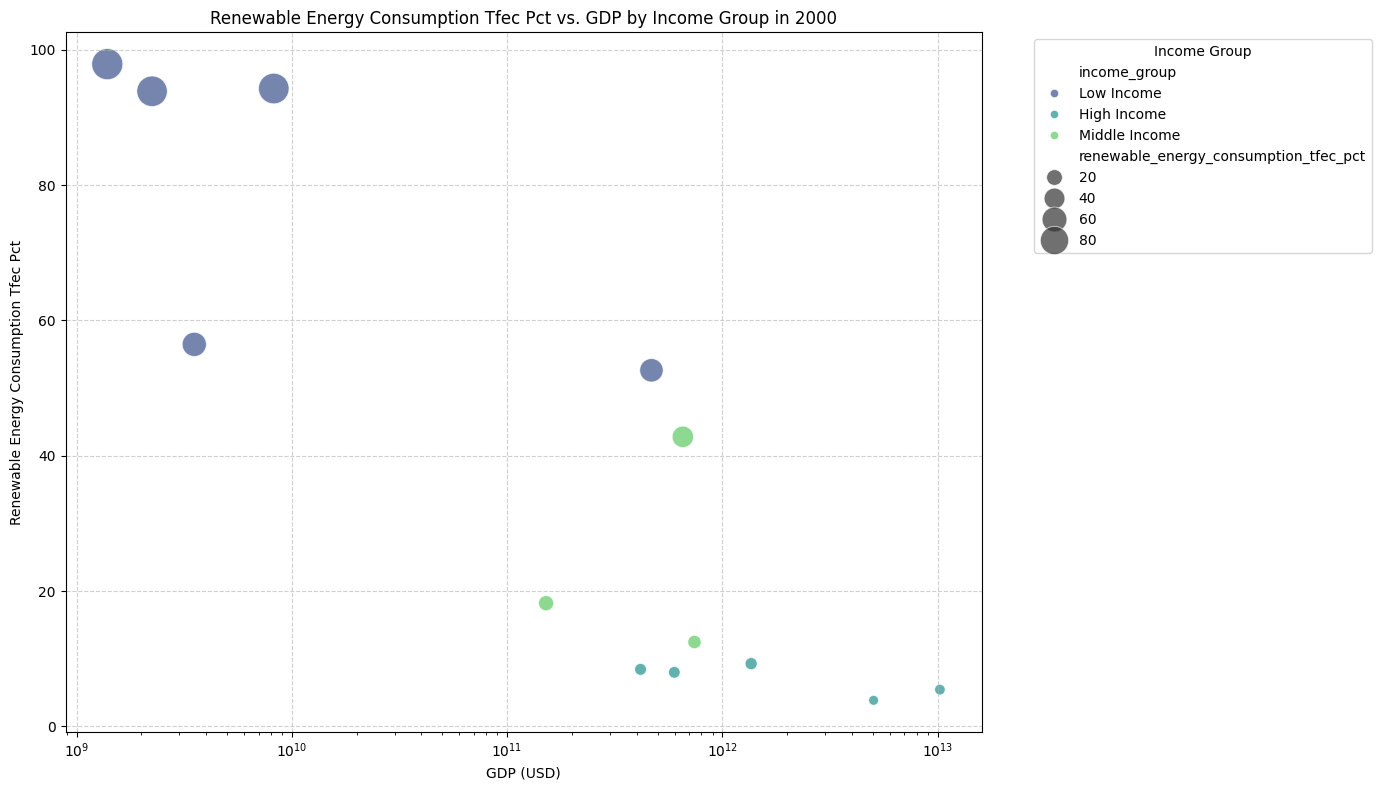

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the energy source to visualize (e.g., renewable_energy_consumption_tfec_pct)
energy_source_col = 'renewable_energy_consumption_tfec_pct'

# Filter for the specific year of interest (2000)
data_for_plot = final_combined_df_with_gdp[
    final_combined_df_with_gdp['yr'] == 2000
].copy()

# Drop rows where GDP or the chosen energy source is NaN for cleaner visualization
data_for_plot.dropna(subset=[energy_source_col, 'gdp_usd', 'income_group'], inplace=True)

# Create the plot
fig = plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data_for_plot,
    x='gdp_usd',
    y=energy_source_col,
    hue='income_group',
    # style='yr', # No need for style by year if only one year is selected
    size=energy_source_col, # Use energy consumption for point size
    sizes=(50, 500),
    palette='viridis',
    alpha=0.7
)

plt.title(f'{energy_source_col.replace("_", " ").title()} vs. GDP by Income Group in 2000')
plt.xlabel('GDP (USD)')
plt.ylabel(f'{energy_source_col.replace("_", " ").title()}')
plt.xscale('log') # GDP often spans several orders of magnitude, so a log scale is useful
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

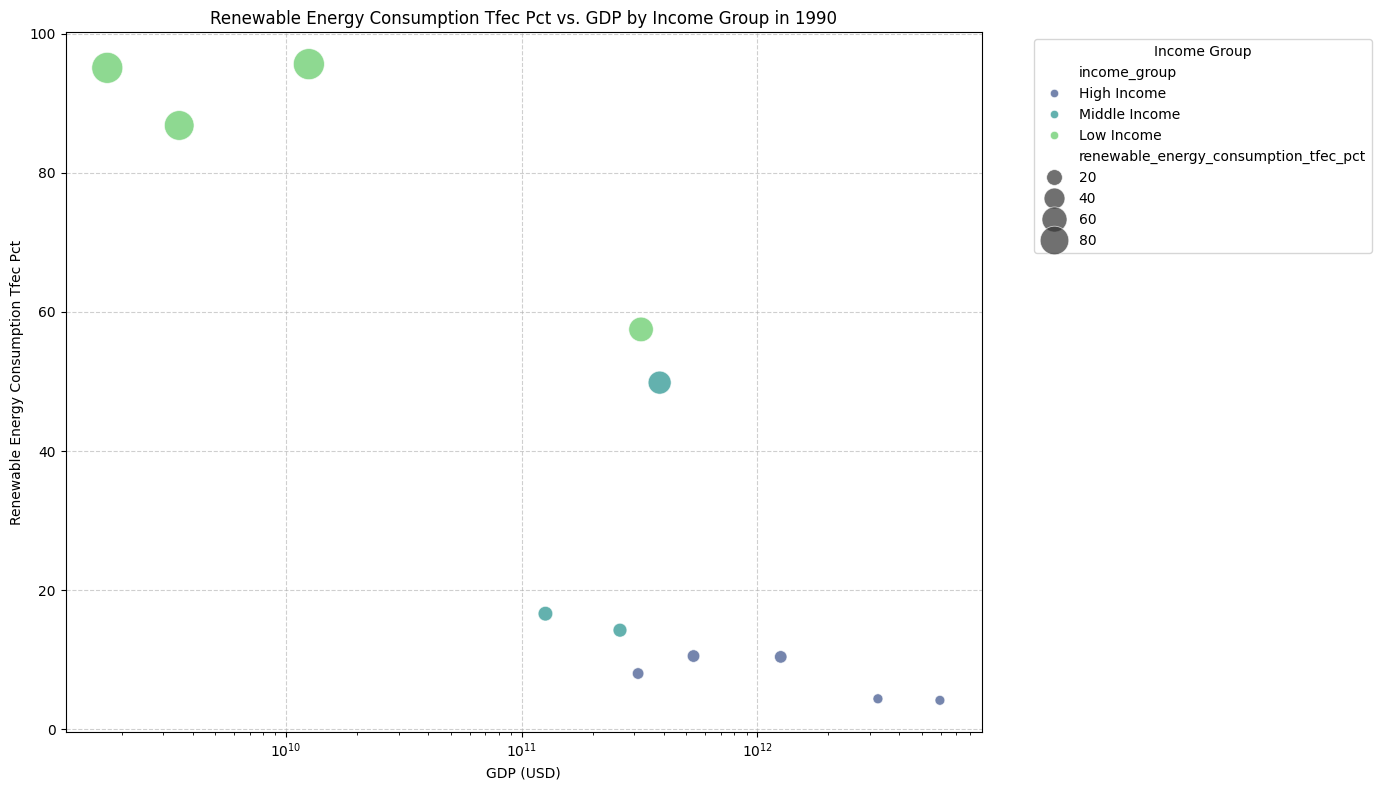

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the energy source to visualize (e.g., renewable_energy_consumption_tfec_pct)
energy_source_col = 'renewable_energy_consumption_tfec_pct'

# Filter for the specific year of interest (1990)
data_for_plot_1990 = final_combined_df_with_gdp[
    final_combined_df_with_gdp['yr'] == 1990
].copy()

# Drop rows where GDP or the chosen energy source is NaN for cleaner visualization
data_for_plot_1990.dropna(subset=[energy_source_col, 'gdp_usd', 'income_group'], inplace=True)

# Create the plot for 1990
fig_1990 = plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data_for_plot_1990,
    x='gdp_usd',
    y=energy_source_col,
    hue='income_group',
    size=energy_source_col, # Use energy consumption for point size
    sizes=(50, 500),
    palette='viridis',
    alpha=0.7
)

plt.title(f'{energy_source_col.replace("_", " ").title()} vs. GDP by Income Group in 1990')
plt.xlabel('GDP (USD)')
plt.ylabel(f'{energy_source_col.replace("_", " ").title()}')
plt.xscale('log') # GDP often spans several orders of magnitude, so a log scale is useful
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

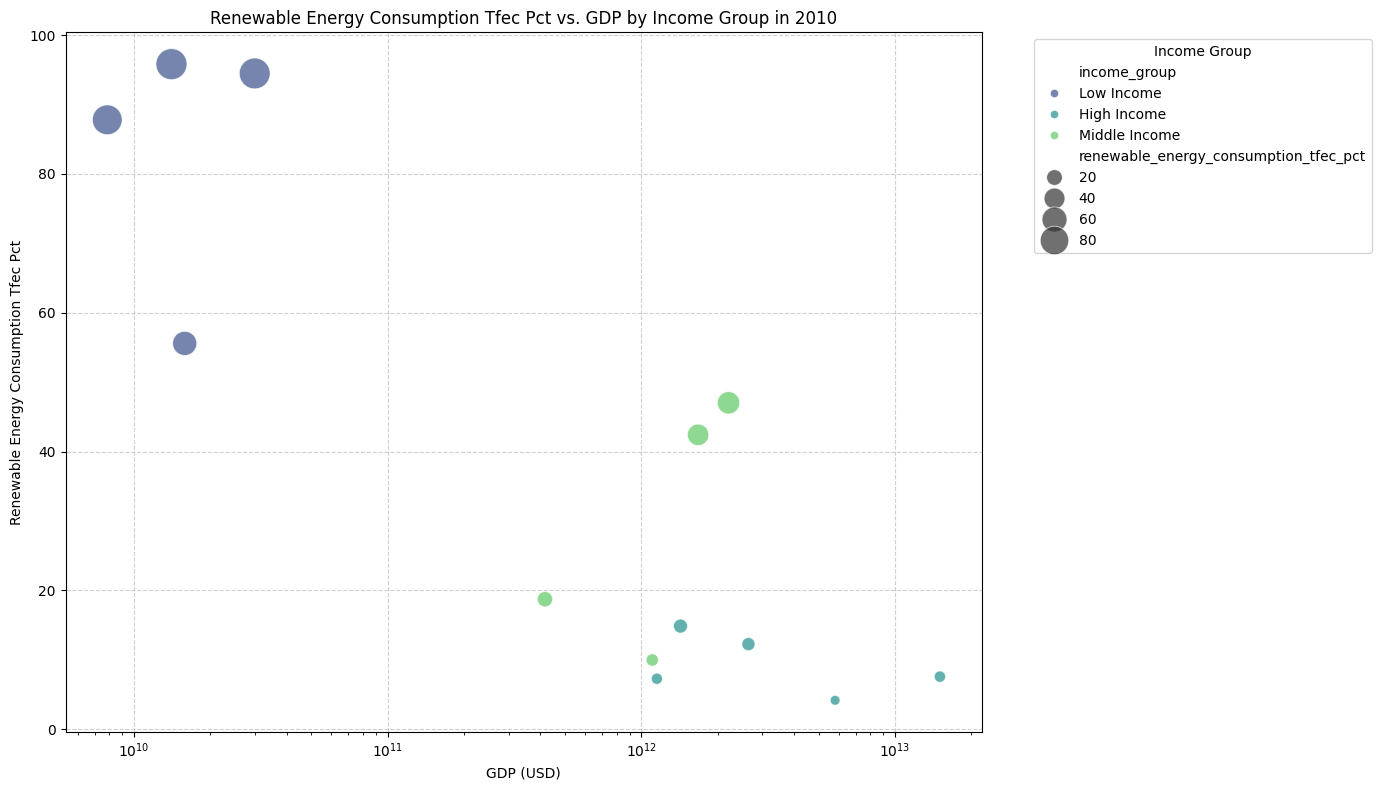

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the energy source to visualize (e.g., renewable_energy_consumption_tfec_pct)
energy_source_col = 'renewable_energy_consumption_tfec_pct'

# Filter for the specific year of interest (2010)
data_for_plot_2010 = final_combined_df_with_gdp[
    final_combined_df_with_gdp['yr'] == 2010
].copy()

# Drop rows where GDP or the chosen energy source is NaN for cleaner visualization
data_for_plot_2010.dropna(subset=[energy_source_col, 'gdp_usd', 'income_group'], inplace=True)

# Create the plot for 2010
fig_2010 = plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data_for_plot_2010,
    x='gdp_usd',
    y=energy_source_col,
    hue='income_group',
    size=energy_source_col, # Use energy consumption for point size
    sizes=(50, 500),
    palette='viridis',
    alpha=0.7
)

plt.title(f'{energy_source_col.replace("_", " ").title()} vs. GDP by Income Group in 2010')
plt.xlabel('GDP (USD)')
plt.ylabel(f'{energy_source_col.replace("_", " ").title()}')
plt.xscale('log') # GDP often spans several orders of magnitude, so a log scale is useful
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()